In [ ]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")

Mitsuba variant: cuda_ad_mono_polarized


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/sionna rt"


 glaishalle	        test10_gml   test18_gleishalle	'test_scene 3'
'glaishalle old file'   test11_gml   test_scene1


In [ ]:
from sionna.rt import load_scene

scene = load_scene("/content/drive/MyDrive/sionna rt/test10_gml/test10_gml/test10_gml.xml")

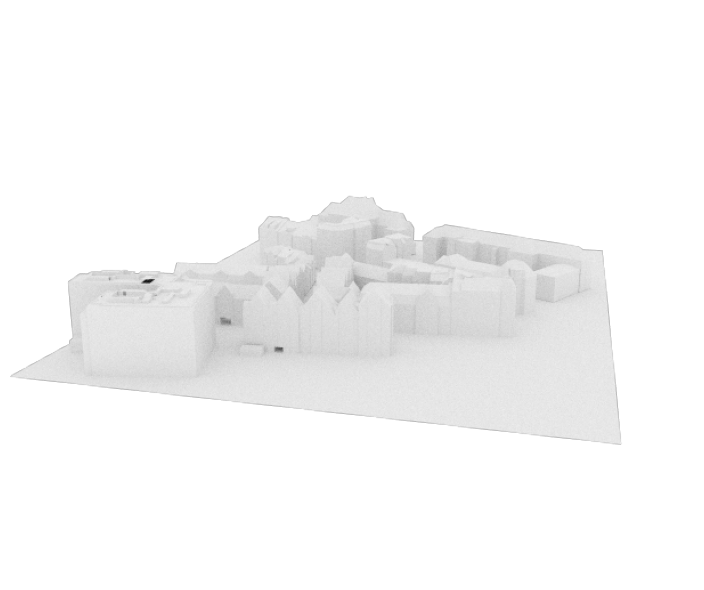

In [ ]:
my_cam = Camera(
    position=[479, 181, 110],
    look_at=[-190, 0, -85]
)

scene.render(
    camera=my_cam,
    resolution=[600, 500],
    num_samples=128
    );

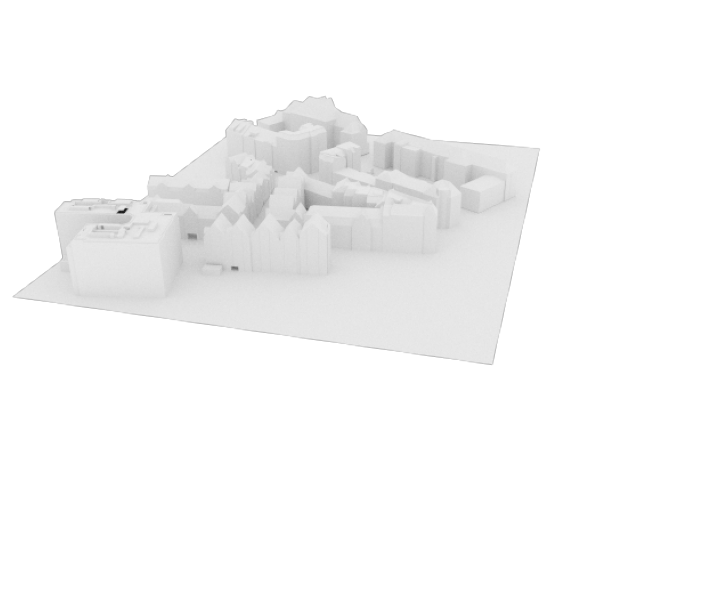

In [ ]:
my_cam = Camera(
    position=[511, 215, 170],
    look_at=[51, 91,-85 ]
)

scene.render(
    camera=my_cam,
    resolution=[600, 500],
    num_samples=512
    );

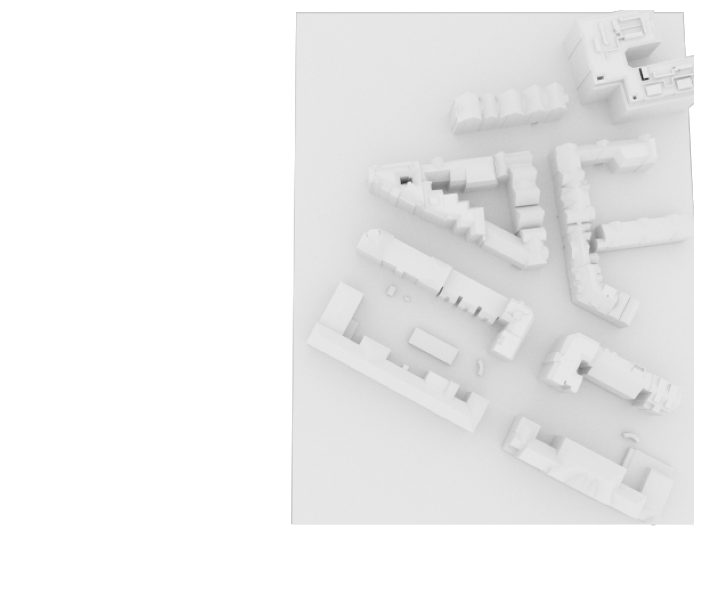

In [ ]:
my_cam = Camera(
    position=[60, 170, 410],
    look_at=[110, 170, 5]
)

scene.render(
    camera=my_cam,
    resolution=[600, 500],
    num_samples=1080
);

In [ ]:
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V"
)

# Create transmitter
tx = Transmitter(
    name="tx1",
    position=[30, 70, 35],

)

scene.add(tx)

# Create receiver
rx = Receiver(
    name="rx1",
    position=[116, 87, 7],

)

scene.add(rx)

# Transmitter points towards receiver
tx.look_at(rx)

In [ ]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

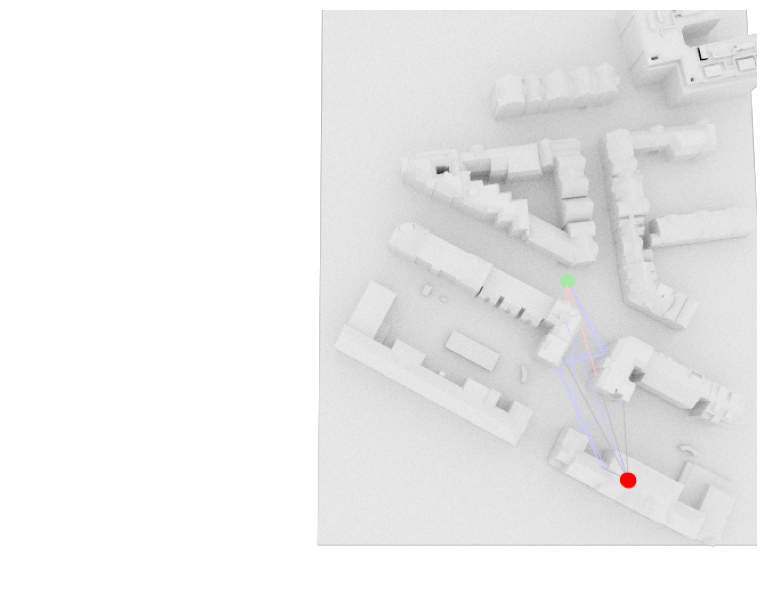

In [ ]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=40);
else:
    scene.preview(paths=paths, clip_at=40);

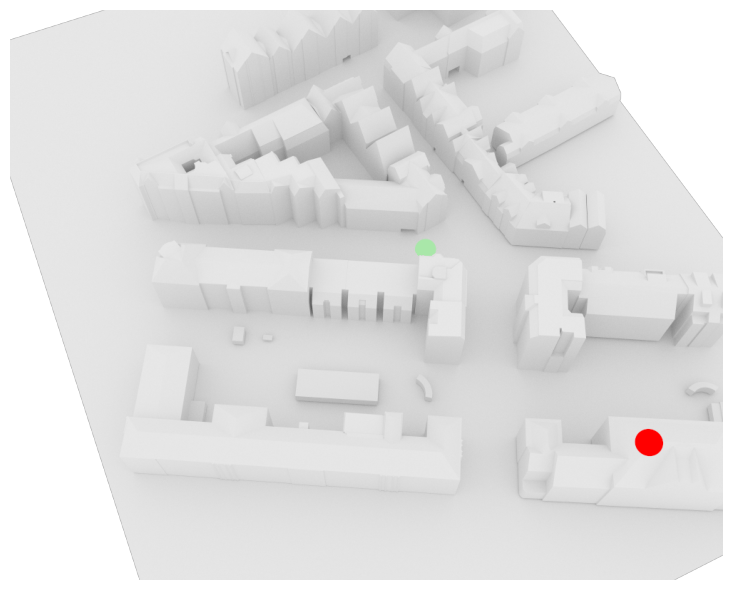

In [ ]:
# Create new camera with different configuration
my_cam = Camera(
    position=[0, 160, 240],
    look_at=[110, 110, 5]
)
# Render scene with new camera*
scene.render(camera=my_cam, resolution=[1000,800], num_samples=1080);


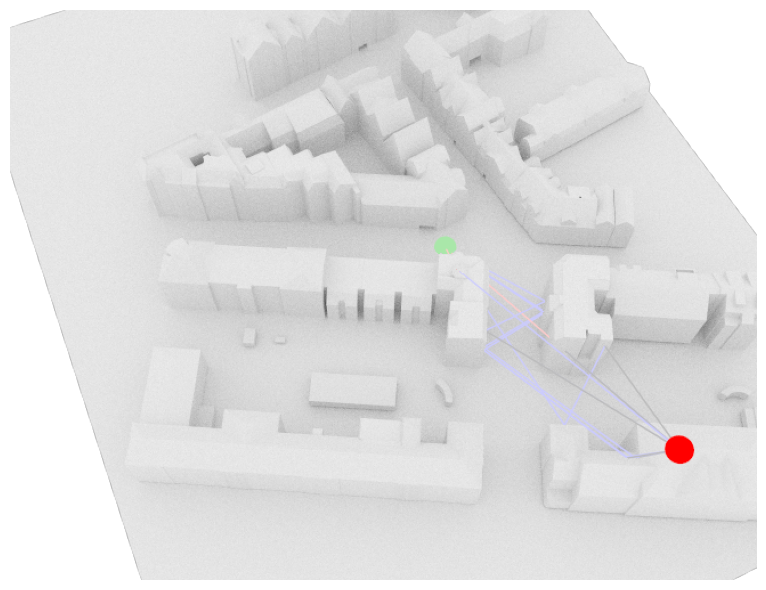

In [ ]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=40);
else:
    scene.preview(paths=paths, clip_at=40);

In [ ]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 1, 1, 1, 10, 1)
Shape of tau:  (1, 1, 1, 1, 10)


Shape of h_freq:  (1, 1, 1, 1, 1, 1024)


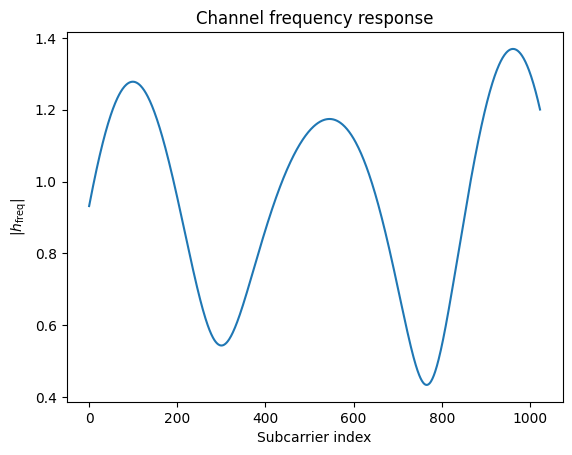

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of h_freq:  (1, 1, 1, 1, 1, 1024)


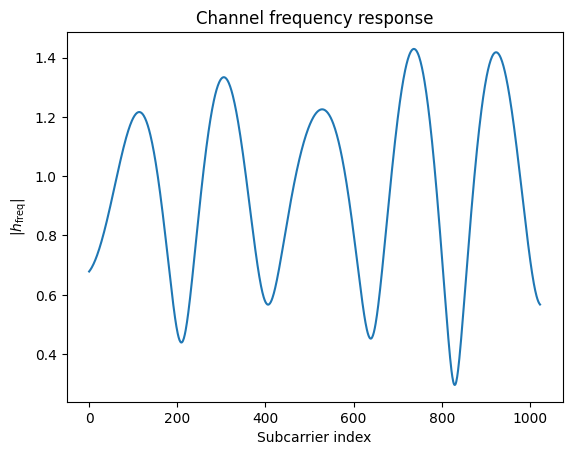

In [ ]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=60e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of taps:  (1, 1, 1, 1, 1, 107)


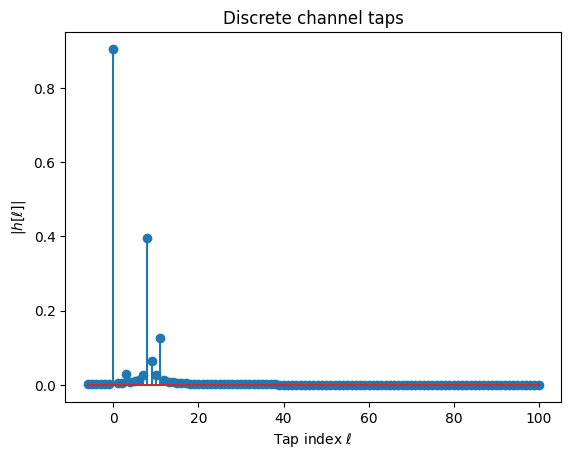

In [ ]:
taps = paths.taps(bandwidth=100e6, # Bandwidth to which the channel is low-pass filtered
                  l_min=-6,        # Smallest time lag
                  l_max=100,       # Largest time lag
                  sampling_frequency=None, # Sampling at Nyquist rate, i.e., 1/bandwidth
                  normalize=True,  # Normalize energy
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");